**Unsupervised ML - Netflix Movies and TV Shows Clustering**

This project focuses on analyzing Netflix content and clustering similar movies and TV shows using NLP and machine learning. The goal is to extract insights that can help in recommendation systems, content strategy, and audience targeting.

**Business Problem:**

Netflix has:

Thousands of movies & TV shows

Different genres, countries, ratings

Problem: How to understand content patterns and group similar content for better decisions?

This project helps to solve this problem.

In [1]:
from google.colab import files
uploaded = files.upload()


Saving NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv to NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv


In [2]:
# data loading
import pandas as pd
df = pd.read_csv("NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [3]:
print(df.shape)

(7787, 12)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB
None


In [5]:
df.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


In [6]:
#  data wrangling
# checking Missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [7]:
# filling missing values
df['country'] = df['country'].fillna("Unknown")

In [8]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [9]:
df['director'] = df['director'].fillna("Unknown")

In [10]:
df['cast'] = df['cast'].fillna("Unknown")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,Unknown,Nasty C,Unknown,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,Unknown,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,0


In [12]:
# formating date
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

# formating duration
df['duration'] = df['duration'].astype(str).str.extract(r'(\d+)')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018.0
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017.0
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123,Dramas,A brilliant group of students become card-coun...,2020.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...",2020-10-19,2005,TV-MA,99,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...,2020.0
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019.0
7784,s7785,Movie,Zulu Man in Japan,Unknown,Nasty C,Unknown,2020-09-25,2019,TV-MA,44,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",2020.0
7785,s7786,TV Show,Zumbo's Just Desserts,Unknown,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020.0


In [13]:
#changeing float time year_added to int.
df['year_added'] = df['year_added'].fillna(df['release_year'])
df['year_added'] = df['year_added'].astype(int)
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123,Dramas,A brilliant group of students become card-coun...,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...",2020-10-19,2005,TV-MA,99,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...,2020
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019
7784,s7785,Movie,Zulu Man in Japan,Unknown,Nasty C,Unknown,2020-09-25,2019,TV-MA,44,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",2020
7785,s7786,TV Show,Zumbo's Just Desserts,Unknown,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020


In [14]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,int64


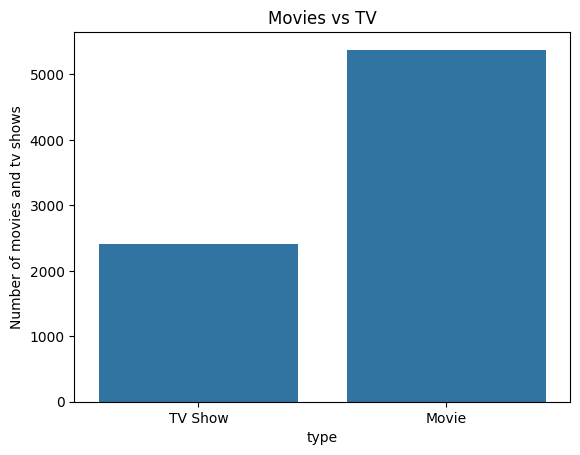

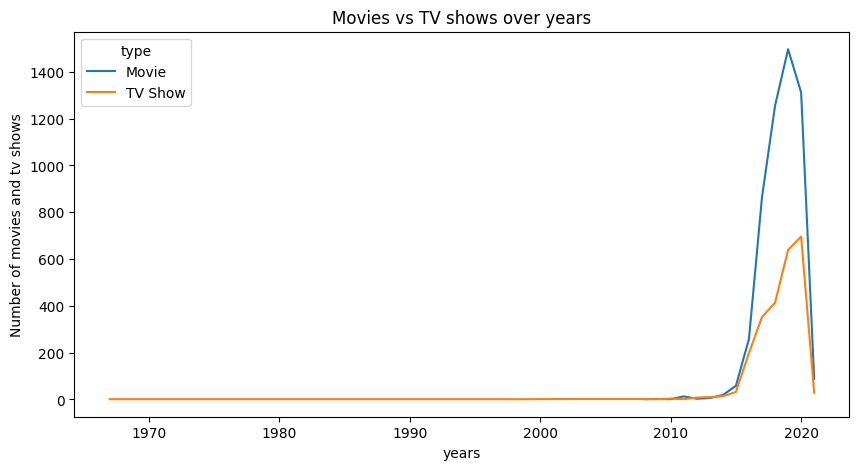

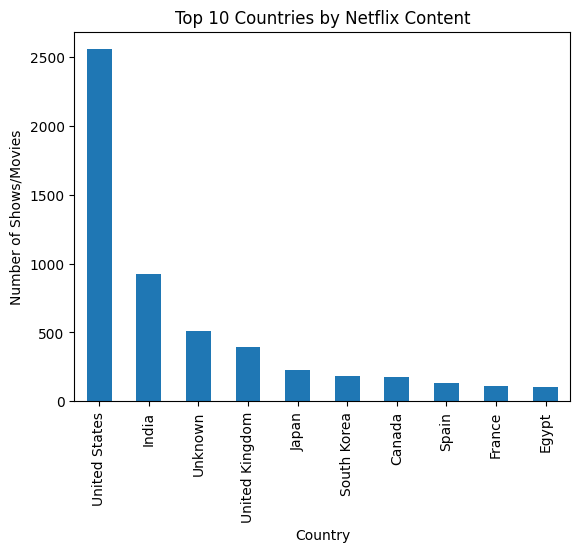

In [15]:
# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Movies vs TV Shows
sns.countplot(x='type', data=df)
plt.xlabel('type')
plt.ylabel('Number of movies and tv shows')
plt.title('Movies vs TV')
plt.show()

# Trend
df.groupby(['year_added','type']).size().unstack().plot(figsize=(10,5))
plt.xlabel("years")
plt.ylabel('Number of movies and tv shows')
plt.title('Movies vs TV shows over years')
plt.show()

# Top Countries
df['country'].value_counts().head(10).plot(kind='bar')
plt.xlabel("Country")
plt.ylabel("Number of Shows/Movies")
plt.title("Top 10 Countries by Netflix Content")
# plt.xticks(rotation=45)
plt.show()

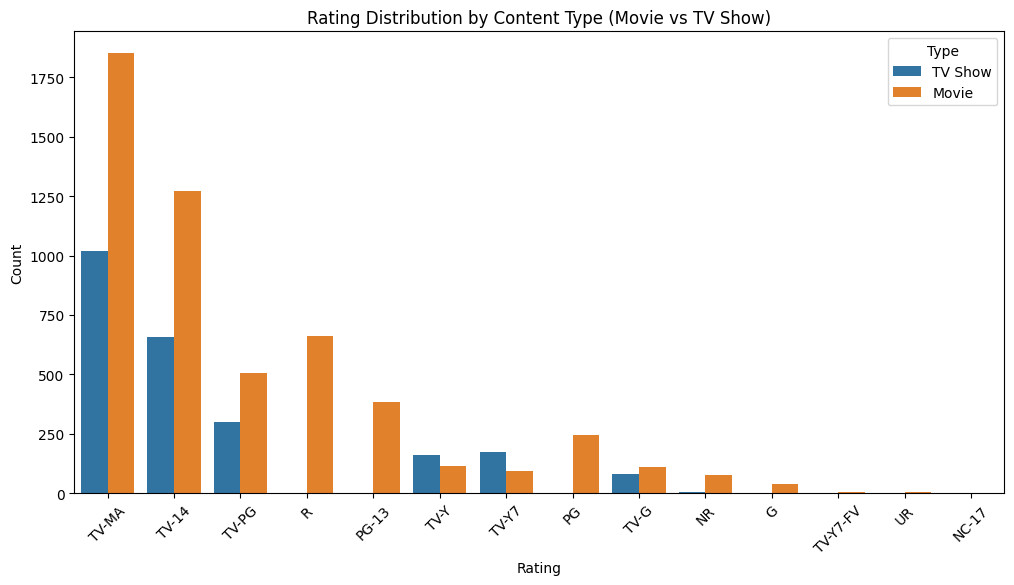

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.countplot(
    x='rating',
    hue='type',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title("Rating Distribution by Content Type (Movie vs TV Show)")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Type")
plt.show()

In [17]:
!pip install nltk scikit-learn seaborn

In [18]:
from scipy.stats import ttest_ind

# Separate groups
movies = df[df['type'] == 'Movie']['year_added'].dropna()
tv_shows = df[df['type'] == 'TV Show']['year_added'].dropna()

# Perform t-test
t_stat, p_value = ttest_ind(movies, tv_shows)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 3.425856952921501
P-Value: 0.0006160296370990919


In [19]:
# NLP
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [20]:
# text cleaning for description
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

df['clean_desc'] = df['description'].apply(clean_text)

In [21]:
df['clean_desc']

,clean_desc
0,future elite inhabit island paradise far crowd...
1,devastating earthquake hits mexico city trappe...
2,army recruit found dead fellow soldiers forced...
3,postapocalyptic world rag doll robots hide fea...
4,brilliant group students become card counting ...
...,...
7782,lebanon civil war deprives zozo family left gr...
7783,scrappy poor boy worms way tycoon dysfunctiona...
7784,documentary south african rapper nasty c hits ...
7785,dessert wizard adriano zumbo looks next willy ...


In [22]:
# feature engineering
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=7000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_desc'])

from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=100)
X_reduced = svd.fit_transform(X)

The Elbow plot does not show a very sharp bend, indicating that the dataset does not have clearly separable clusters. Therefore, an approximate value of K=6 was chosen based on gradual slope change and further validated using silhouette score.

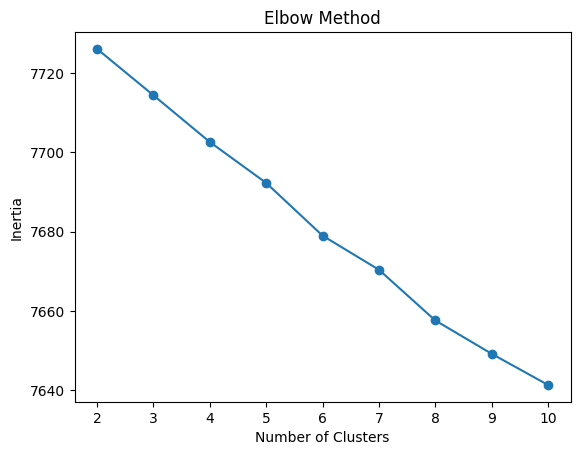

In [23]:
# deciding number of clusters by elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2,11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [24]:
from sklearn.metrics import silhouette_score
for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    print(k, silhouette_score(X, labels))

2 0.0008437374329917452
3 0.0011582437840167135
4 0.0015482187017732667
5 0.0019465896624093848
6 0.0025553333996022154
7 0.002780324157482741
8 0.0034057361558653704
9 0.003725657461980406
10 0.003915198650697152


In [25]:
#in clusteing we are using 2 model
# first one is k-means clustering.
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
df['cluster_kmeans'] = kmeans.fit_predict(X)
df['cluster_kmeans']

,cluster_kmeans
0,5
1,5
2,5
3,5
4,5
...,...
7782,4
7783,4
7784,5
7785,5


The dendrogram does not show a clear separation between clusters, indicating overlapping data points. A horizontal cut at an approximate distance level suggests around 4–6 clusters. Therefore, 5 clusters were selected for hierarchical clustering to maintain consistency with K-Means and ensure interpretability.



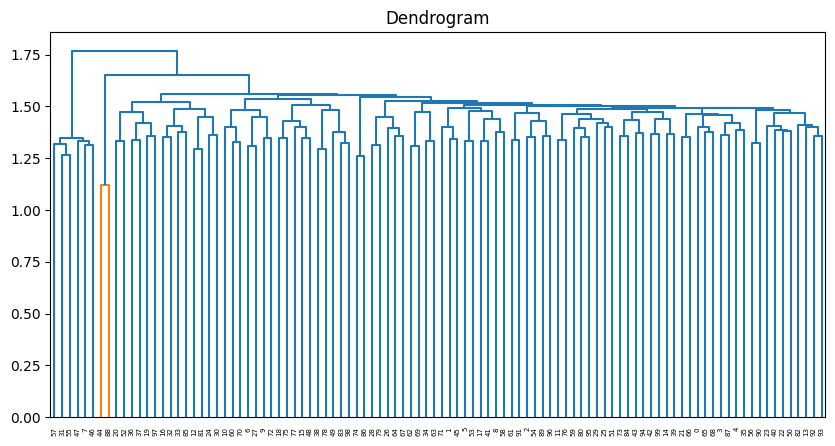

In [26]:
from scipy.cluster.hierarchy import dendrogram, linkage

sample = X[:100].toarray()
linked = linkage(sample, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

In [27]:
# hierarchial
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=6)
df['cluster_hc'] = hc.fit_predict(X.toarray())
df['cluster_hc']

,cluster_hc
0,0
1,0
2,0
3,0
4,0
...,...
7782,0
7783,0
7784,0
7785,0


In [28]:
# model evaluating k-means clustering by silhouette_score.
from sklearn.metrics import silhouette_score

score = silhouette_score(X, df['cluster_kmeans'])
print("Silhouette Score:", score)

Silhouette Score: 0.0025553333996022154


In [29]:
# model evaluating hierarchial clustering by silhouette_score.
from sklearn.metrics import silhouette_score

score_h = silhouette_score(X, df['cluster_hc'])
print("Silhouette Score:", score_h)

Silhouette Score: -0.0026856979053972545


I used silhouette score as the primary evaluation metric because it is well-suited for unsupervised clustering, where ground truth labels are not available. It measures both intra-cluster cohesion and inter-cluster separation. Additionally, I complemented it with the Elbow method and dendrogram analysis to ensure the chosen number of clusters is meaningful and interpretable

Silhouette score alone is not sufficient because it tends to improve slightly with higher cluster counts. Therefore, I also considered interpretability and visual methods like the Elbow plot and dendrogram to avoid over-segmentation

Since clustering is unsupervised, silhouette score is preferred as it evaluates both compactness and separation, but I validated results using Elbow method and dendrogram for robustness.

In [30]:
terms = tfidf.get_feature_names_out()

for i in range(6):
    center = kmeans.cluster_centers_[i]
    words = [terms[ind] for ind in center.argsort()[-10:]]
    print(f"Cluster {i}: {words}")

Cluster 0: ['family', 'finds', 'wife', 'father', 'life', 'young woman', 'young man', 'woman', 'young', 'man']
Cluster 1: ['friends', 'home', 'family', 'finds', 'york city', 'city', 'life', 'york', 'new york', 'new']
Cluster 2: ['friends', 'girl', 'students', 'falls', 'student', 'life', 'high school', 'high', 'school', 'love']
Cluster 3: ['women', 'love', 'must', 'one', 'two young', 'lives', 'young', 'friends', 'find', 'two']
Cluster 4: ['time', 'friends', 'woman', 'world', 'young', 'life', 'father', 'save', 'must', 'family']
Cluster 5: ['takes', 'lives', 'three', 'friends', 'one', 'young', 'series', 'documentary', 'world', 'life']


In [31]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X)

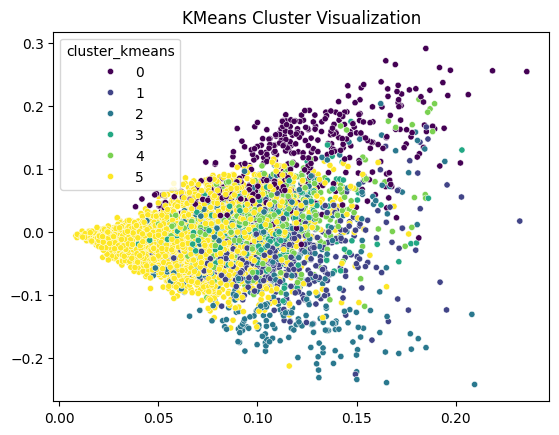

In [32]:
sns.scatterplot(
    x=X_reduced[:,0],
    y=X_reduced[:,1],
    hue=df['cluster_kmeans'],
    palette='viridis',
    s=20
)

plt.title("KMeans Cluster Visualization")
plt.show()

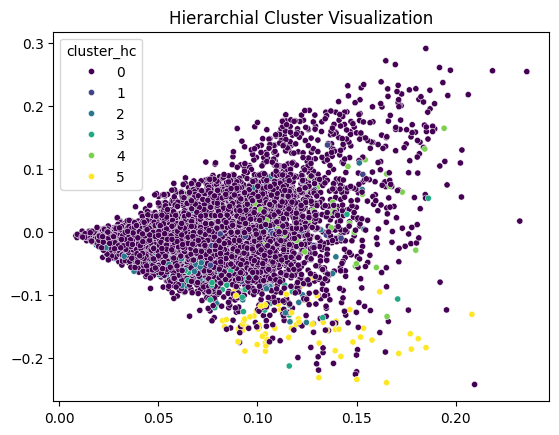

In [33]:
sns.scatterplot(
    x=X_reduced[:,0],
    y=X_reduced[:,1],
    hue=df['cluster_hc'],
    palette='viridis',
    s=20
)

plt.title("Hierarchial Cluster Visualization")
plt.show()

**Conclusion:**

In this project, Netflix content data was analyzed using exploratory data analysis and NLP-based clustering techniques. The analysis revealed that Netflix has significantly expanded its content after 2015, with a growing focus on TV Shows. The United States and India contribute the majority of content, and most titles fall under mature audience ratings such as TV-MA and TV-14.

TF-IDF was used to convert textual descriptions into numerical features, followed by clustering using K-Means and Hierarchical methods. The Elbow method and dendrogram were used to estimate the number of clusters. K-Means performed slightly better based on silhouette score, although the overall scores were low due to overlapping content themes, which is common in text data.

Dimensionality reduction using TruncatedSVD was applied to improve clustering performance and visualize clusters. Hypothesis testing was also conducted to statistically validate differences in content distribution.

💼 ✅ BUSINESS IMPACT (VERY IMPORTANT)
Write this 👇

🎯 1. Content Recommendation
Clustering helps group similar movies and shows, improving recommendation systems by suggesting related content to users.

🎯 2. Content Strategy
Insights from EDA show Netflix’s shift toward TV Shows, helping stakeholders decide future investment areas.

🎯 3. Audience Targeting
Rating distribution analysis helps identify target audience segments (e.g., mature vs family content).

🎯 4. Global Expansion
Country-wise analysis highlights key markets, guiding regional content production and acquisition strategies.

🚀 ✅ PROJECT STORY (HOW TO EXPLAIN IN INTERVIEW)
Say this confidently:

“I started with exploratory data analysis to understand content distribution across countries, types, and years. Then I applied NLP techniques like TF-IDF to convert text into numerical form. Using clustering algorithms like K-Means and Hierarchical clustering, I grouped similar content. I used Elbow method and dendrogram to determine cluster count and evaluated models using silhouette score. Finally, I improved performance using dimensionality reduction and interpreted clusters to derive business insights.”


In [34]:
import os
print(os.getcwd())

/content


In [37]:
import pickle

pickle.dump(kmeans, open("/content/model/kmeans.pkl", "wb"))
pickle.dump(tfidf, open("/content/model/tfidf.pkl", "wb"))
# the models will be stored in model folder then i downloaded them and added inside model folder in netflix project.